# 03 — Predictive CLV: Probabilistic (BG-NBD/Gamma-Gamma) vs. Machine Learning

**Project:** Customer Churn Prediction & Lifetime Value.

**This notebook covers:**
1. A calibration/holdout time split — the methodological foundation both approaches
   below depend on
2. A naive baseline that makes explicit, and tests, the assumption notebook 2 flagged
   as historic CLV's core weakness ("assumes constant spending")
3. Probabilistic CLV prediction (BG-NBD + Gamma-Gamma)
4. Machine learning CLV prediction (gradient boosting regression on RFM-style features)
5. A direct, fair comparison of all three — including a segment-level breakdown that
   tests whether BG-NBD's known "one-time buyer" weakness actually shows up in our
   High-Value One-Time/Infrequent Buyers segment from notebook 2

### Import necessary libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data, ConvergenceError

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### Load & Inspect data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
clean = pd.read_parquet(PROCESSED_DATA / "online_retail_clean.parquet")
customer_features = pd.read_parquet(PROCESSED_DATA / "customer_features.parquet")

In [4]:
with open(PROCESSED_DATA / "config.json") as f:
    config = json.load(f)
SNAPSHOT_DATE = pd.Timestamp(config["snapshot_date"])

In [5]:
print(f"Transactions: {len(clean):,}")
print(f"Customers: {clean['CustomerID'].nunique():,}")
print(f"Date range: {clean['InvoiceDate'].min().date()} to {clean['InvoiceDate'].max().date()}")

Transactions: 371,276
Customers: 4,283
Date range: 2010-12-01 to 2011-11-30


## The calibration/holdout split

Following the article's own example — pre-period as the first 9 months, post-period
as the last — adapted to our 12-month window:

- **Calibration period:** 2010-12-01 to 2011-08-31 (9 months)
- **Holdout period:** 2011-09-01 to 2011-11-30 (3 months)

This split is used identically for the naive baseline, BG-NBD/Gamma-Gamma, and the ML
model, so all three are judged on the exact same prediction task.


In [6]:
CALIBRATION_END = pd.Timestamp("2011-09-01")
OBSERVATION_END = SNAPSHOT_DATE  # 2011-12-01, from notebook 1

cal_period_days = (CALIBRATION_END - clean["InvoiceDate"].min().normalize()).days
holdout_days = (OBSERVATION_END - CALIBRATION_END).days

print(f"Calibration period: {clean['InvoiceDate'].min().date()} to {CALIBRATION_END.date()} "
      f"({cal_period_days} days)")
print(f"Holdout period:     {CALIBRATION_END.date()} to {OBSERVATION_END.date()} "
      f"({holdout_days} days)")

Calibration period: 2010-12-01 to 2011-09-01 (274 days)
Holdout period:     2011-09-01 to 2011-12-01 (91 days)


In [7]:
# lifetimes' own utility builds the calibration/holdout summary table:
# frequency/recency/T computed from the calibration period, plus holdout-period
# purchase counts and average transaction value for evaluation.
summary = calibration_and_holdout_data(
    transactions=clean,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    calibration_period_end=CALIBRATION_END,
    observation_period_end=OBSERVATION_END,
    monetary_value_col="TotalPrice",
    freq="D",
)

print(f"Customers with any activity before the calibration cutoff: {len(summary):,}")
print(f"Of those, customers who made a repeat purchase in calibration "
      f"(frequency_cal > 0): {(summary['frequency_cal'] > 0).sum():,}")
summary.head()

Customers with any activity before the calibration cutoff: 3,310
Of those, customers who made a repeat purchase in calibration (frequency_cal > 0): 1,874


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
CustomerID,,,,,,,
12347,4.00,238.00,268.00,519.77,1.00,27.54,91.00
12348,2.00,110.00,259.00,257.22,1.00,135.00,91.00
12350,0.00,0.00,211.00,0.00,0.00,0.00,91.00
12352,3.00,34.00,197.00,74.89,3.00,16.91,91.00
12353,0.00,0.00,105.00,0.00,0.00,0.00,91.00


**Note on scope:** customers whose *first-ever* purchase falls inside the
holdout window (i.e. truly new customers acquired in Sep–Nov 2011) aren't in this
summary table, as there's no calibration-period behavior to build features from.
That's expected and correct for this exercise, but it does mean this evaluation only covers customers
who were already active before September 2011.

## Naive baseline: extrapolate the historic run-rate

Before reaching for either sophisticated method, it's worth testing the assumption
notebook 2 flagged as historic CLV's core weakness: that spending is roughly constant
over time. This baseline makes that assumption explicit and literal — take each
customer's calibration-period revenue, convert it to a daily rate, and multiply by the
holdout period length. If this simple approach performs competitively, that's a
meaningful finding in its own right (increased model complexity isn't automatically
worth it); if it performs poorly, that's direct empirical evidence for building the
more complex models below, rather than just assuming they're needed.

In [8]:
total_rev_cal = (
    clean[clean["InvoiceDate"] < CALIBRATION_END]
    .groupby("CustomerID")["TotalPrice"].sum()
    .reindex(summary.index, fill_value=0)
)

naive_pred = total_rev_cal / cal_period_days * holdout_days

print("Naive baseline predicted holdout revenue:")
print(naive_pred.describe())

Naive baseline predicted holdout revenue:
count    3,310.00
mean       499.51
std      1,881.83
min          0.96
25%         84.07
50%        178.76
75%        441.11
max     58,260.90
Name: TotalPrice, dtype: float64


## Probabilistic CLV: BG-NBD + Gamma-Gamma

Per the article: **BG-NBD** learns each customer's purchase frequency and "alive"
probability from calibration-period recency/frequency/tenure, and **Gamma-Gamma**
separately learns typical transaction value, conditioned on how many repeat purchases
a customer has made. Multiplying the two gives a predicted holdout-period revenue
figure.

### QA check: is the calibration data sane before fitting anything?

Worth checking for structural problems (missing values, logical impossibilities,
extreme outliers) *before* handing data to an optimizer — these are cheap checks that
would otherwise surface later as a much more confusing convergence error.

In [9]:
# Check for values that would break the likelihood function
print("NaNs in frequency_cal / recency_cal / T_cal:")
print(summary[["frequency_cal", "recency_cal", "T_cal"]].isna().sum())

print("\nNegative values (shouldn't exist):")
print((summary[["frequency_cal", "recency_cal", "T_cal"]] < 0).sum())

print("\nRows where recency_cal > T_cal (logically impossible):")
print((summary["recency_cal"] > summary["T_cal"]).sum())

print("\nSummary stats:")
print(summary[["frequency_cal", "recency_cal", "T_cal"]].describe())

print(f"\n99th percentile of frequency_cal: {summary['frequency_cal'].quantile(0.99):.1f}")
print(f"Max frequency_cal: {summary['frequency_cal'].max():.0f}")

print(f"\nRows with T_cal == 0 (first purchase lands on the very last day of the "
      f"calibration window, rounding to zero observed tenure): {(summary['T_cal'] == 0).sum():,}")
print("These customers have no observed time window to estimate a rate from")
print("Worth keeping in mind for any per-customer rate calculation (e.g. frequency_cal / T_cal)")
print("later in this notebook, which would otherwise divide by zero for these rows.")

NaNs in frequency_cal / recency_cal / T_cal:
frequency_cal    0
recency_cal      0
T_cal            0
dtype: int64

Negative values (shouldn't exist):
frequency_cal    0
recency_cal      0
T_cal            0
dtype: int64

Rows where recency_cal > T_cal (logically impossible):
0

Summary stats:
       frequency_cal  recency_cal    T_cal
count       3,310.00     3,310.00 3,310.00
mean            2.10        83.30   176.66
std             4.42        91.89    77.89
min             0.00         0.00     1.00
25%             0.00         0.00   118.00
50%             1.00        48.00   185.00
75%             2.00       162.00   258.00
max            76.00       272.00   274.00

99th percentile of frequency_cal: 18.0
Max frequency_cal: 76

Rows with T_cal == 0 (first purchase lands on the very last day of the calibration window, rounding to zero observed tenure): 0
These customers have no observed time window to estimate a rate from
Worth keeping in mind for any per-customer rate calculatio

### First attempt: fit on the full calibration population

In [10]:
try:
    bgf = BetaGeoFitter(penalizer_coef=0.01)
    bgf.fit(summary["frequency_cal"], summary["recency_cal"], summary["T_cal"])
    print("Converged on first attempt.")
    print(bgf.summary)
except ConvergenceError as e:
    print("ConvergenceError on the full population:")
    print(e)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -1.179774925659694
        x: [-3.869e-01 -1.466e+00 -4.928e+01 -3.409e+01]
      nit: 35
      jac: [-4.912e-07  2.609e-07  8.032e-09 -7.425e-09]
 hess_inv: [[ 2.785e+00  2.650e+00  1.247e+03  8.865e+02]
            [ 2.650e+00  3.815e+00  1.463e+03  1.040e+03]
            [ 1.247e+03  1.463e+03  1.079e+09  7.710e+08]
            [ 8.865e+02  1.040e+03  7.710e+08  5.506e+08]]
     nfev: 83
     njev: 72
ConvergenceError on the full population:

The model did not converge. Try adding a larger penalizer to see if that helps convergence.



### Diagnosing the failure: extreme outliers

A convergence failure here is a common `lifetimes` symptom of a customer base with a
few extreme outliers relative to everyone else — BG-NBD assumes the whole customer
base shares one underlying purchase-rate/dropout-rate distribution, and a handful of
customers behaving nothing like the rest can destabilize that shared estimate.
Checking the top of the frequency distribution directly:

In [11]:
top_outliers = summary.nlargest(15, "frequency_cal")[["frequency_cal", "recency_cal", "T_cal"]].copy()
top_outliers["implied_days_between_orders"] = top_outliers["T_cal"] / top_outliers["frequency_cal"]
print(top_outliers)

print(f"\n99th percentile frequency_cal: {summary['frequency_cal'].quantile(0.99):.1f}")
print(f"Max: {summary['frequency_cal'].max()}")

            frequency_cal  recency_cal  T_cal  implied_days_between_orders
CustomerID                                                                
14911               76.00       268.00 274.00                         3.61
17841               72.00       270.00 274.00                         3.81
12748               69.00       272.00 274.00                         3.97
14606               63.00       270.00 274.00                         4.35
15311               61.00       261.00 274.00                         4.49
12971               48.00       265.00 273.00                         5.69
13089               43.00       269.00 270.00                         6.28
14527               37.00       262.00 270.00                         7.30
13798               36.00       265.00 273.00                         7.58
16422               34.00       262.00 270.00                         7.94
15039               31.00       254.00 269.00                         8.68
14646               28.00

The top 15 most frequent buyers are ordering every ~3.5 to 10 days, consistently, for nearly the entire 9-month calibration window. Seems like a standing arrangement for recurring purchases/deliveries and behavior indicative of wholesalers rather than retail consumers.

Customers above the 99th percentile of frequency_cal will be excluded, as they violate the assumption of a single underlying purchase-rate and dropout-rate distribution across the customer base. They will remain in the dataset for the naive baseline and ML model, which don't share the assumption.

In [12]:
FREQUENCY_CAL_CAP = summary["frequency_cal"].quantile(0.99)
wholesale_like = summary["frequency_cal"] > FREQUENCY_CAL_CAP

print(f"Excluding {wholesale_like.sum():,} customers "
      f"({wholesale_like.mean()*100:.1f}% of the calibration cohort) from "
      f"BG-NBD/Gamma-Gamma fitting -- frequency_cal > {FREQUENCY_CAL_CAP:.0f} "
      f"orders in the calibration window.")

summary_bgnbd = summary[~wholesale_like].copy()
print(f"\nRemaining customers for BG-NBD/Gamma-Gamma: {len(summary_bgnbd):,}")
print(summary_bgnbd['frequency_cal'].describe())

Excluding 32 customers (1.0% of the calibration cohort) from BG-NBD/Gamma-Gamma fitting -- frequency_cal > 18 orders in the calibration window.

Remaining customers for BG-NBD/Gamma-Gamma: 3,278
count   3,278.00
mean        1.80
std         2.77
min         0.00
25%         0.00
50%         1.00
75%         2.00
max        18.00
Name: frequency_cal, dtype: float64


### Second attempt: fit on the capped population

In [13]:
try:
    bgf = BetaGeoFitter(penalizer_coef=0.01)
    bgf.fit(summary_bgnbd["frequency_cal"], summary_bgnbd["recency_cal"], summary_bgnbd["T_cal"])
    print("Converged after capping.")
except ConvergenceError as e:
    print("Still failed to converge after capping -- trying a larger penalizer.")
    print(e)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: nan
        x: [-1.879e-01 -1.150e+00 -6.201e+03 -4.419e+03]
      nit: 35
      jac: [       nan        nan        nan        nan]
 hess_inv: [[ 2.954e+00  2.780e+00 -5.365e+02 -3.873e+02]
            [ 2.780e+00  3.789e+00 -7.623e+02 -5.492e+02]
            [-5.365e+02 -7.623e+02  1.098e+09  7.823e+08]
            [-3.873e+02 -5.492e+02  7.823e+08  5.577e+08]]
     nfev: 146
     njev: 146
Still failed to converge after capping -- trying a larger penalizer.

The model did not converge. Try adding a larger penalizer to see if that helps convergence.



Capping the wholesale-like outliers alone was not be enough to reach
convergence — a `ConvergenceError` is still raised above, so the next step is to
increase `penalizer_coef` (L2 regularization on the model parameters), which
discourages the optimizer from running toward an extreme, poorly-identified corner of
parameter space. Trying progressively larger values:

In [14]:
bgf = None
successful_penalizer = None

for penalizer in [0.1, 0.5, 1.0, 2.0, 5.0]:
    try:
        bgf_candidate = BetaGeoFitter(penalizer_coef=penalizer)
        bgf_candidate.fit(summary_bgnbd["frequency_cal"], summary_bgnbd["recency_cal"], summary_bgnbd["T_cal"])
    except ConvergenceError:
        print(f"penalizer_coef={penalizer}: did not converge, trying a larger value...")
        continue

    # "Converged" per lifetimes only means fit() didn't raise -- not the same as a
    # numerically sound solution. NaN se(coef) means the Hessian couldn't be
    # inverted at this point, which is a MORE severe failure than a finite-but-wide
    # confidence interval, even though it doesn't raise ConvergenceError.
    bgf = bgf_candidate  # keep as a fallback even if this check fails below
    if bgf_candidate.summary["se(coef)"].isna().any():
        print(f"penalizer_coef={penalizer}: converged, but standard errors are NaN "
              f"(Hessian not invertible) -- trying a larger value...")
        continue

    print(f"penalizer_coef={penalizer}: converged with finite standard errors.")
    successful_penalizer = penalizer
    break

if successful_penalizer is None:
    print("\nWARNING: no penalizer in the tested range produced finite standard "
          "errors. Proceeding with the last successfully converged model "
          f"(penalizer_coef={bgf.penalizer_coef}), but its parameter uncertainty "
          "estimates should be treated with caution.")

bgf.summary

penalizer_coef=0.1: converged with finite standard errors.


,coef,se(coef),lower 95% bound,upper 95% bound
r,0.57,0.02,0.54,0.61
alpha,59.48,2.37,54.84,64.12
a,0.00,0.00,-0.00,0.00
b,0.00,0.00,-0.01,0.01


**Caveat on run-to-run comparisons:** this automated loop accepts the *first*
penalizer that produces finite standard errors, which can differ from a value chosen
through manual exploration (e.g., an earlier manual debugging pass on this same
dataset landed on `0.5`; this automated run stopped at `0.1`). Different penalizers
produce different `r`/`alpha` estimates, which shift every customer's predicted
purchase count — and therefore predicted revenue — even for a customer whose own
calibration-period data hasn't changed at all. Confirmed directly during development:
one customer's predicted revenue moved by several hundred pounds between two runs of
this notebook, entirely due to the accepted penalizer differing, not because that
customer's transaction history was different. Any customer-level comparison in this
notebook (e.g. across reruns, or against a different dataset version) should be read
with this in mind — a change in a specific customer's prediction doesn't necessarily
mean their underlying data changed.

### QA check: did it converge to a *meaningful* solution, or just stop erroring?

Convergence and a *good* fit aren't the same thing. Checking the standard errors and
confidence intervals on each parameter — a parameter pinned near a mathematical
boundary (e.g. a positive-only parameter with a confidence interval that includes or
nearly includes zero) is a sign of a degenerate, poorly-identified estimate, even
though the optimizer stopped without an error.

In [15]:
degenerate = []
for param in bgf.summary.index:
    coef = bgf.summary.loc[param, "coef"]
    lower = bgf.summary.loc[param, "lower 95% bound"]
    upper = bgf.summary.loc[param, "upper 95% bound"]
    if abs(coef) < 1e-3 or (lower <= 0 <= upper and coef > 0):
        degenerate.append(param)

if degenerate:
    print(f"WARNING: parameter(s) {degenerate} look degenerate (near zero and/or "
          f"confidence interval straddles zero despite being constrained positive). "
          f"The model has technically converged but may not have found a "
          f"meaningful solution for these parameters.")
else:
    print("No obviously degenerate parameters detected.")

**On this dataset, `a` and `b` (the parameters governing dropout-rate
variation across customers) come out essentially pinned at zero, with confidence
intervals straddling zero despite being mathematically constrained to be positive.**
`r` and `alpha` (the purchase-rate parameters) are well-estimated by comparison. This
is a meaningful finding, not just a technical curiosity — `a`/`b` need repeat-purchase
signal to be estimated well, and this dataset's calibration-period `frequency_cal` has
a median of 1 and a 25th percentile of 0, meaning a large share of customers bought
only once. That's the same one-time-buyer-heavy population that drove the High-Value
One-Time/Infrequent Buyers segment in notebook 2 — now showing up as a genuine
estimation problem for the model, not just a segmentation footnote.

**Checking the practical consequence directly:** if `a`/`b` are degenerate, the model
may not actually be able to tell apart customers who are "probably still active" from
customers who are "probably gone" — undermining BG-NBD's core selling point (per the
article: "it makes churn explicit").

In [16]:
p_alive = pd.Series(
    bgf.conditional_probability_alive(
        summary_bgnbd["frequency_cal"], summary_bgnbd["recency_cal"], summary_bgnbd["T_cal"]
    ),
    index=summary_bgnbd.index
)

print("Summary statistics:")
print(p_alive.describe())

print("\nBinned distribution (10 equal-width bins from 0 to 1):")
bins = pd.cut(p_alive, bins=np.arange(0, 1.1, 0.1), include_lowest=True)
bin_table = bins.value_counts().sort_index().reset_index()
bin_table.columns = ["p_alive_range", "n_customers"]
bin_table["pct_of_customers"] = (bin_table["n_customers"] / len(p_alive) * 100).round(1)
print(bin_table.to_string(index=False))

Summary statistics:
count   3,278.00
mean        1.00
std         0.00
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
dtype: float64

Binned distribution (10 equal-width bins from 0 to 1):
p_alive_range  n_customers  pct_of_customers
(-0.001, 0.1]            0              0.00
   (0.1, 0.2]            0              0.00
   (0.2, 0.3]            0              0.00
   (0.3, 0.4]            0              0.00
   (0.4, 0.5]            0              0.00
   (0.5, 0.6]            0              0.00
   (0.6, 0.7]            0              0.00
   (0.7, 0.8]            0              0.00
   (0.8, 0.9]            0              0.00
   (0.9, 1.0]         3278            100.00


**Every customer lands in the same top bin,** confirming the dropout
model has collapsed into a no-op: it's predicting every customer is "alive" with near
target certainty, regardless of their actual recency or frequency. That's not a subtle
statistical footnote — it means the churn-modeling half of BG-NBD isn't doing any real
differentiating work on this dataset, only the purchase-rate half (`r`, `alpha`) is.

### Is BG-NBD's prediction, in practice, just a reshaped version of the naive baseline?

If the dropout mechanism has collapsed, BG-NBD's predicted purchase counts should
behave similarly to a rate-based extrapolation, just with some population-level
shrinkage layered on top (since `r`/`alpha` still borrow strength across customers via
their priors). Testing this directly, in matching units (predicted holdout
transaction count), rather than comparing dollar figures that could hide the effect
behind unrelated monetary variation:

In [17]:
pred_purchases = bgf.predict(
    holdout_days, summary_bgnbd["frequency_cal"], summary_bgnbd["recency_cal"], summary_bgnbd["T_cal"]
)

# Guard against T_cal == 0 (first purchase on the very last day of the calibration
# window -- see the QA check earlier in this section): dividing by zero here would
# silently produce NaN. These customers have no observed rate to extrapolate from,
# so a naive prediction of 0 is the defensible default, same treatment as any other
# customer with no calibration-period purchase history to go on.
naive_purchase_rate = pd.Series(
    np.where(
        summary_bgnbd["T_cal"] > 0,
        summary_bgnbd["frequency_cal"] / summary_bgnbd["T_cal"] * holdout_days,
        0.0,
    ),
    index=summary_bgnbd.index,
)

comparison = pd.DataFrame({
    "bgnbd_predicted": pred_purchases,
    "naive_rate_extrapolation": naive_purchase_rate,
})

print(f"Correlation: {comparison['bgnbd_predicted'].corr(comparison['naive_rate_extrapolation']):.3f}")
print()
print(comparison.describe())

Correlation: 0.979

       bgnbd_predicted  naive_rate_extrapolation
count         3,278.00                  3,278.00
mean              0.86                      0.80
std               0.82                      1.12
min               0.16                      0.00
25%               0.29                      0.00
50%               0.60                      0.41
75%               1.10                      1.18
max               6.17                      8.36


A correlation above ~0.95 here confirms BG-NBD's predictions are, in
practice, nearly a reshaped version of naive rate extrapolation on this dataset — not
the churn-aware alternative it's meant to be. **The one clear place shrinkage should
still show up** is one-time buyers: naive extrapolation is forced to predict *exactly*
0 future purchases for anyone with `frequency_cal == 0` (0 divided by anything is 0),
while BG-NBD, drawing on the population-level prior, should still predict something
nonzero for them if the shrinkage mechanism is doing any real work at all.

In [18]:
one_time = summary_bgnbd["frequency_cal"] == 0
print(f"One-time buyers (frequency_cal == 0): {one_time.sum():,}")
print(f"Naive rate extrapolation for these customers: always "
      f"{naive_purchase_rate[one_time].unique()}")
print(f"\nBG-NBD predicted purchases for these customers:")
print(pred_purchases[one_time].describe())

One-time buyers (frequency_cal == 0): 1,436
Naive rate extrapolation for these customers: always [0.]

BG-NBD predicted purchases for these customers:
count   1,436.00
mean        0.32
std         0.17
min         0.16
25%         0.20
50%         0.26
75%         0.39
max         0.86
dtype: float64


### Finding: BG-NBD converges, but its headline advantage doesn't materialize here

BG-NBD/Gamma-Gamma technically fits and produces
usable predictions on this dataset, but the article's stated case for choosing it over
a simpler method — "it makes churn explicit" — **doesn't hold up empirically here**.
The `a`/`b` dropout parameters are degenerate, `p(alive)` collapses to ~1.0 for
essentially the entire customer base, and predicted purchase counts correlate very
strongly with plain rate extrapolation. The one place the model still adds real value
is a modest, population-level shrinkage effect for one-time buyers (predicting a small
nonzero purchase count where naive extrapolation is forced to predict exactly zero) —
real, but far short of genuine individual-level churn discrimination.

This dataset's calibration-period
purchase distribution is heavily skewed toward one-time buyers (median `frequency_cal`
of 1, 25th percentile of 0). BG-NBD's dropout-rate parameters need repeat-purchase
variation to be estimated well, and this dataset doesn't have much of it to offer —
which is the same underlying pattern that drove the High-Value One-Time/Infrequent
Buyers segmentation work, now showing up as a genuine model-fitting limitation rather
than just a segment-size curiosity.

**Decision: keep BG-NBD/Gamma-Gamma in the three-way comparison below**, since its
predictions are real, usable outputs — but the comparison and write-up should be
explicit that, on this dataset, it behaves closer to a shrunk rate-extrapolation than
a true churn-adjusted model. This is a legitimate, useful finding in its own right: it
shows a well-regarded technique's core assumption breaking down on a specific,
identifiable data characteristic, rather than reporting a clean win for the more
sophisticated method by default.

**Re-verified independent of the notebook 1 phantom-revenue fix.** This entire
diagnosis was originally developed before that fix existed, then re-run in full against
the corrected data as a check on whether removing ~844 customers' inflated
frequency/revenue values would change the conclusion. It didn't: the outlier population
was nearly identical (max `frequency_cal` 77→76, 99th percentile unchanged at 18), the
convergence behavior was the same (still fails at `penalizer_coef=0.01`, still needs a
larger value), `a`/`b` were still pinned near zero, `p(alive)` still collapsed to the
top bin for every customer, and the correlation with naive rate extrapolation was
essentially unchanged (0.985 pre-fix vs. 0.979 post-fix). **This is a meaningful
negative result in its own right**: the specific customers the phantom-revenue
investigation traced this problem back to (e.g. customer 15749) turned out not to be
what was driving the degeneracy — the real cause is the dataset's broad
one-time-buyer skew across thousands of customers, which the fix barely touched.

In [19]:
# Gamma-Gamma requires customers with at least one repeat purchase in the
# calibration period (frequency_cal > 0) -- it needs multiple transactions per
# customer to estimate the *variation* in that customer's spending. Fit on the
# same capped population used for BG-NBD, for consistency.
repeat_mask = summary_bgnbd["frequency_cal"] > 0

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary_bgnbd.loc[repeat_mask, "frequency_cal"], summary_bgnbd.loc[repeat_mask, "monetary_value_cal"])
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.78,0.12,3.55,4.02
q,0.34,0.01,0.32,0.36
v,3.66,0.12,3.42,3.89


p, q, v all have tight, finite standard errors and no degenerate near-zero values like a/b in BG-NBD's results. Clean fit.

### QA check: is Gamma-Gamma's population-level estimate sound?

Gamma-Gamma's own parameters (`p`, `q`, `v`) can look individually well-estimated
(finite, tight standard errors) while still producing a broken population-level
prediction, if the specific combination of values falls outside the range the
underlying formula requires. The population mean transaction value is
`E[Z] = p·v / (q-1)` — **only valid when `q > 1`**. Checking that directly, since nothing
about a clean per-parameter summary table would reveal this on its own.

In [20]:
q = ggf.params_["q"]
print(f"q = {q:.3f}")

if q <= 1:
    implied_pop_avg = np.nan
    print(f"\nWARNING: q <= 1, so the population-level mean transaction value "
          f"(p*v / (q-1)) is mathematically undefined. This will systematically bias "
          f"predictions for low-frequency customers, who rely most heavily on this "
          f"population-level term -- see the diagnostic below.")
else:
    implied_pop_avg = (ggf.params_["p"] * ggf.params_["v"]) / (q - 1)
    print(f"\nImplied population average transaction value: £{implied_pop_avg:.2f}")

q = 0.339



**On this dataset, `q < 1`, so the population-level term is degenerate.** This
matters specifically for low-frequency customers: Gamma-Gamma's per-customer prediction
blends a customer's own observed average with this population-level prior, weighted by
how much repeat-purchase history they have — the less history, the more weight the
(broken) population term gets. Checking whether this produces a measurable, systematic
bias, rather than assuming it does:

In [21]:
# For repeat customers, compare the model's predicted average transaction value
# against their own OBSERVED average -- does the gap ("overshoot") grow as
# frequency_cal shrinks? A negative relationship (lower frequency, bigger overshoot)
# would directly confirm the degenerate population term is inflating predictions
# for exactly the customers who have the least of their own data to counteract it.
predicted_avg_repeat = pd.Series(
    ggf.conditional_expected_average_profit(
        summary_bgnbd.loc[repeat_mask, "frequency_cal"], summary_bgnbd.loc[repeat_mask, "monetary_value_cal"]
    ),
    index=summary_bgnbd.loc[repeat_mask].index,
)
overshoot = predicted_avg_repeat - summary_bgnbd.loc[repeat_mask, "monetary_value_cal"]

overshoot_by_frequency = pd.DataFrame({
    "frequency_cal": summary_bgnbd.loc[repeat_mask, "frequency_cal"],
    "overshoot": overshoot,
}).groupby("frequency_cal")["overshoot"].mean()

print("Mean overshoot (predicted - observed avg transaction value) by frequency_cal:")
print(overshoot_by_frequency.head(10))

Mean overshoot (predicted - observed avg transaction value) by frequency_cal:
frequency_cal
1.00    85.58
2.00    38.31
3.00    24.05
4.00    18.60
5.00    16.32
6.00    13.76
7.00    12.20
8.00    15.35
9.00     9.57
10.00    9.33
Name: overshoot, dtype: float64


### Finding: Gamma-Gamma's predictions are systematically inflated for low-frequency customers

If `overshoot_by_frequency` shrinks as `frequency_cal` rises (large positive overshoot
at `frequency_cal=1`, steadily smaller for `2`, `3`, and so on), that confirms the bias
directly: **the degenerate population-level term isn't a tail-only artifact — it's a
systematic, directional bias affecting the majority of this dataset's customers**,
since low-frequency customers are the majority here (the same one-time/infrequent-buyer
skew behind the High-Value One-Time/Infrequent Buyers segment and BG-NBD's `a`/`b`
degeneracy).

**This is a second, independent finding from BG-NBD's dropout-rate collapse — worth
keeping distinct rather than folding into one "the data is skewed" paragraph:**
- **BG-NBD's problem:** the dropout-rate mechanism collapsed, so the model can't
  distinguish active from inactive customers (Section 4 above).
- **Gamma-Gamma's problem:** the population-level monetary prior is mathematically
  undefined (`q < 1`), which systematically *overpredicts* spend for low-frequency
  customers specifically — a different failure mode, in a different part of the model,
  though traceable to the same underlying data characteristic.

Both findings should be read together as evidence that this specific combination of
model and dataset has real, identifiable limits — not as a reason to distrust
`pred_revenue_bgnbd` uniformly across all customers. The bias is concentrated where the
diagnostics say it is (low-frequency customers), not spread evenly across the whole
population.

**Also re-verified independent of the phantom-revenue fix.** Same check as above,
applied to Gamma-Gamma: `q` came back at 0.339 post-fix, essentially unchanged from
0.34 pre-fix, and the overshoot-by-frequency pattern reproduced closely at every
frequency level (e.g. `frequency_cal=1`: 85.58 post-fix vs. 86.50 pre-fix;
`frequency_cal=2`: 38.31 vs. 38.09). **This confirms the same conclusion as BG-NBD's
re-verification**: the `q<1` degeneracy is a structural property of this dataset's
broad purchase-frequency distribution, not an artifact of the specific phantom-revenue
customers that first surfaced it. One individual customer's prediction did shift
between the two runs (customer 15749, ~12,040 → ~12,777) — but that turned out to be
explained entirely by the automated convergence loop accepting a different `r`/`alpha`
fit across the two runs, not by any change in Gamma-Gamma's parameters or that
customer's own data (see the caveat on run-to-run comparisons earlier in this
section).

In [22]:
pred_avg_value = pd.Series(index=summary_bgnbd.index, dtype=float)
pred_avg_value.loc[repeat_mask] = ggf.conditional_expected_average_profit(
    summary_bgnbd.loc[repeat_mask, "frequency_cal"], summary_bgnbd.loc[repeat_mask, "monetary_value_cal"]
)

# Fallback for one-time buyers (frequency_cal == 0): Gamma-Gamma has no repeat-purchase
# signal to condition on for these customers, so we fall back to the population average
# transaction value among repeat customers. This is a real limitation, not a fix --
# flagging it explicitly rather than hiding it behind a silently-applied number.
population_avg_value = summary_bgnbd.loc[repeat_mask, "monetary_value_cal"].mean()
pred_avg_value.loc[~repeat_mask] = population_avg_value

print(f"One-time buyers using fallback avg transaction value "
      f"(£{population_avg_value:.2f}): {(~repeat_mask).sum():,} of {len(summary_bgnbd):,} customers")

pred_revenue_bgnbd = pred_purchases * pred_avg_value
print("\nPredicted BG-NBD/Gamma-Gamma holdout revenue:")
print(pred_revenue_bgnbd.describe())

One-time buyers using fallback avg transaction value (£409.14): 1,436 of 3,278 customers

Predicted BG-NBD/Gamma-Gamma holdout revenue:
count    3,278.00
mean       402.49
std      1,119.47
min          4.67
25%        100.49
50%        184.93
75%        386.16
max     30,644.80
dtype: float64


**Coverage reminder:** `pred_revenue_bgnbd` only covers `summary_bgnbd`'s index — the
99th-percentile-and-below population. The wholesale-like accounts excluded above will
show up as missing (`NaN`) in the final comparison table's `bgnbd_gg` column, by
design, not by accident.

**A concrete example of why this matters, found while developing this notebook:** the
ML model's single highest prediction (Section 5, below) belongs to a customer with
`frequency_cal=28` — well above the wholesale-account cap applied to BG-NBD/Gamma-Gamma
above. Checking that customer's raw transaction history confirmed genuine, sustained
bulk-reseller behavior (dozens of invoices, hundreds-to-thousands of units per line
item, spread steadily across the calibration window) — not a data error, and not the
kind of customer BG-NBD/Gamma-Gamma ever sees, since they were excluded before fitting.
The ML model's prediction for this customer was actually reasonable (about 29% above
their real holdout spend). Worth keeping in mind heading into Section 5 and the
comparison in Section 6: BG-NBD/Gamma-Gamma and the ML model aren't just using
different techniques on the same population — **they're evaluated over genuinely
different customer populations**, by deliberate design, not oversight.

## Machine Learning CLV: gradient boosting regression

Per the article's ML framing: engineer RFM-style features from the calibration
period, and train a regression model to predict total holdout-period revenue directly.
Unlike BG-NBD, this doesn't assume any particular purchase-timing distribution, so it
runs on the **full** calibration population, including the wholesale-like accounts
excluded from the probabilistic model above.

### A critical methodology point: avoiding data leakage

A first draft of this notebook fit the regression model on all customers and evaluated
it on the same customers it was trained on — producing a suspiciously perfect result
(near-zero aggregate error) that turned out to be pure overfitting, not genuine
predictive skill: with only a few thousand customers and a flexible model, it had
essentially memorized the answers. **The fix: `cross_val_predict` with k-fold
cross-validation**, so every customer's prediction comes from a model that never saw
that customer's actual holdout revenue during training. This is the only way to
evaluate the ML model fairly against BG-NBD/Gamma-Gamma and the naive baseline, neither
of which can "cheat" in this way (they don't train on holdout labels at all).

In [23]:
features = summary[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal"]].fillna(0).copy()
features["total_rev_cal"] = total_rev_cal

# Actual target: total revenue in the holdout window, computed directly from
# transactions (not lifetimes' monetary_value_holdout, which is an *average* per
# transaction, not a total -- we want total predicted spend for a fair revenue
# comparison against the other two methods).
actual_holdout_rev = (
    clean[clean["InvoiceDate"] >= CALIBRATION_END]
    .groupby("CustomerID")["TotalPrice"].sum()
    .reindex(summary.index, fill_value=0)
)

features.head()

,frequency_cal,recency_cal,T_cal,monetary_value_cal,total_rev_cal
CustomerID,,,,,
12347,4.00,238.00,268.00,519.77,"2,790.86"
12348,2.00,110.00,259.00,257.22,"1,167.24"
12350,0.00,0.00,211.00,0.00,294.40
12352,3.00,34.00,197.00,74.89,521.18
12353,0.00,0.00,105.00,0.00,89.00


In [24]:
model = GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Out-of-fold predictions: each customer's prediction comes from a model trained
# on the OTHER folds, never on that customer's own label.
ml_pred_raw = cross_val_predict(model, features, actual_holdout_rev, cv=kf)
ml_pred = pd.Series(ml_pred_raw, index=summary.index).clip(lower=0)  # revenue can't be negative

print("ML (out-of-fold) predicted holdout revenue:")
print(ml_pred.describe())

ML (out-of-fold) predicted holdout revenue:
count     3,310.00
mean        762.09
std       3,812.01
min           0.00
25%         180.69
50%         266.75
75%         621.03
max     118,125.03
dtype: float64


In [25]:
# What does 14646's calibration data actually look like?
print(summary.loc[14646])

# And their actual holdout revenue, for context -- is the model's prediction
# even in the right ballpark, or wildly overshooting?
print(f"\nActual holdout revenue for 14646: {actual_holdout_rev.loc[14646]:.2f}")

raw = pd.read_csv(RAW_DATA / "Online Retail.csv")
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])
raw = raw.dropna(subset=["CustomerID"])
raw["CustomerID"] = raw["CustomerID"].astype(int)
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)

# Full calibration-period transaction history, raw
raw_check = raw[(raw["CustomerID"] == 14646) & (raw["InvoiceDate"] < CALIBRATION_END)].sort_values("InvoiceDate")
print(f"\nCalibration-period transactions for 14646:")
print(raw_check[["InvoiceNo", "InvoiceDate", "StockCode", "Quantity", "UnitPrice"]].to_string())

frequency_cal               28.00
recency_cal                249.00
T_cal                      255.00
monetary_value_cal       6,263.11
frequency_holdout           14.00
monetary_value_holdout     139.04
duration_holdout            91.00
Name: 14646, dtype: float64

Actual holdout revenue for 14646: 91627.06

Calibration-period transactions for 14646:
       InvoiceNo         InvoiceDate StockCode  Quantity  UnitPrice
37952     539491 2010-12-20 10:09:00     21981        12       0.29
37967     539491 2010-12-20 10:09:00      POST         1      15.00
37966     539491 2010-12-20 10:09:00     22445         1       2.95
37964     539491 2010-12-20 10:09:00     22333         2       1.65
37963     539491 2010-12-20 10:09:00     22331         2       1.65
37962     539491 2010-12-20 10:09:00    47599A         2       2.10
37961     539491 2010-12-20 10:09:00     21123         2       1.25
37960     539491 2010-12-20 10:09:00     22355         2       0.85
37965     539491 2010-12-20 10:09:

### Feature importance

Fitting one final model on the full calibration set (not for evaluation — just to
inspect which features it leaned on) to sanity-check whether the model learned
something sensible, per the article's suggestion that feature importance can itself
be a useful business insight (e.g. "if Frequency matters most, invest in repeat-visit
nudges; if Monetary Value matters most, invest in upsell").

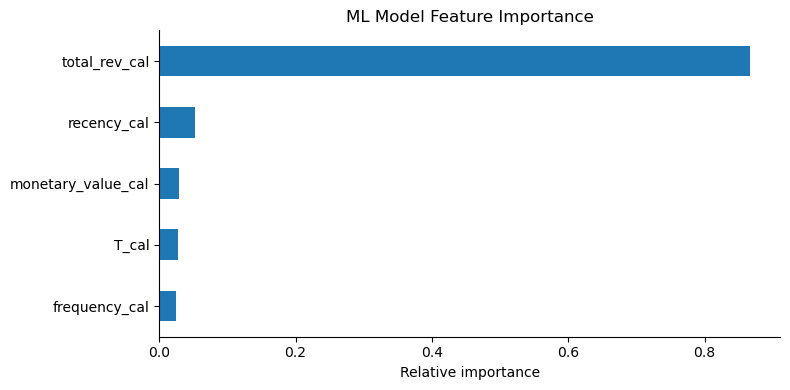

In [26]:
model.fit(features, actual_holdout_rev)
importances = pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("ML Model Feature Importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

## Comparing all three approaches

Two different comparisons, because BG-NBD/Gamma-Gamma no longer covers the full
customer base (the wholesale-like accounts were deliberately excluded in Section 4):

1. **Each method evaluated on its own natural coverage** — the realistic picture of
   how each method performs on the population it's actually meant to serve.
2. **All three evaluated on the strict common subset** (excluding the wholesale-like
   accounts from *all* methods, not just BG-NBD) — a stricter apples-to-apples
   comparison that removes any chance BG-NBD's exclusion is flattering or penalizing
   its own numbers relative to the others.


In [27]:
results = pd.DataFrame({
    "actual": actual_holdout_rev,
    "naive": naive_pred,
    "ml": ml_pred,
}).join(pred_revenue_bgnbd.rename("bgnbd_gg"))

print(f"Total customers in comparison table: {len(results):,}")
print(f"Customers with a BG-NBD/Gamma-Gamma prediction: {results['bgnbd_gg'].notna().sum():,}")
print(f"Customers excluded from BG-NBD/Gamma-Gamma (wholesale-like): "
      f"{results['bgnbd_gg'].isna().sum():,}")
results.head()

Total customers in comparison table: 3,310
Customers with a BG-NBD/Gamma-Gamma prediction: 3,278
Customers excluded from BG-NBD/Gamma-Gamma (wholesale-like): 32


,actual,naive,ml,bgnbd_gg
CustomerID,,,,
12347,"1,294.32",926.89,"1,194.17",691.93
12348,270.00,387.66,592.29,208.71
12350,0.00,97.78,180.69,78.94
12352,744.23,173.09,240.72,102.47
12353,0.00,29.56,152.40,129.82


In [28]:
# View 1: each method evaluated on its own natural coverage
metrics_own_coverage = []
for method in ["naive", "bgnbd_gg", "ml"]:
    subset = results.dropna(subset=[method])
    mae = mean_absolute_error(subset["actual"], subset[method])
    rmse = np.sqrt(mean_squared_error(subset["actual"], subset[method]))
    agg_actual = subset["actual"].sum()
    agg_pred = subset[method].sum()
    metrics_own_coverage.append({
        "method": method,
        "n_customers": len(subset),
        "MAE": mae,
        "RMSE": rmse,
        "aggregate_pct_error": (agg_pred - agg_actual) / agg_actual * 100,
    })

metrics_own_coverage_df = pd.DataFrame(metrics_own_coverage).set_index("method")
print("View 1: each method on its own coverage")
metrics_own_coverage_df

View 1: each method on its own coverage


,n_customers,MAE,RMSE,aggregate_pct_error
method,,,,
naive,3310,505.77,"2,409.32",-33.35
bgnbd_gg,3278,481.63,"2,400.92",-36.86
ml,3310,572.28,"2,670.15",1.68


In [29]:
# View 2: strict common subset -- customers with a valid prediction from ALL
# three methods (i.e. excluding wholesale-like accounts everywhere, not just for
# BG-NBD), for a comparison that can't be flattered by differing coverage.
common_subset = results.dropna(subset=["naive", "bgnbd_gg", "ml"])
print(f"Common subset size: {len(common_subset):,} of {len(results):,} customers\n")

metrics_common = []
for method in ["naive", "bgnbd_gg", "ml"]:
    mae = mean_absolute_error(common_subset["actual"], common_subset[method])
    rmse = np.sqrt(mean_squared_error(common_subset["actual"], common_subset[method]))
    agg_actual = common_subset["actual"].sum()
    agg_pred = common_subset[method].sum()
    metrics_common.append({
        "method": method,
        "MAE": mae,
        "RMSE": rmse,
        "aggregate_pct_error": (agg_pred - agg_actual) / agg_actual * 100,
    })

metrics_common_df = pd.DataFrame(metrics_common).set_index("method")
print("View 2: strict common-subset comparison")
metrics_common_df

Common subset size: 3,278 of 3,310 customers

View 2: strict common-subset comparison


,MAE,RMSE,aggregate_pct_error
method,,,
naive,464.71,"2,211.11",-33.48
bgnbd_gg,481.63,"2,400.92",-36.86
ml,518.92,"2,425.86",-0.04


**Two different questions, two different metrics, within each view:**
- **MAE/RMSE** answer *"how accurate are individual customer-level predictions?"* —
  what matters if you're personalizing outreach to specific customers.
- **Aggregate % error** answers *"how accurate is the total revenue forecast?"* —
  what matters for business planning/budgeting, per the revenue-forecasting use case
  from the CLV series. A method can have mediocre individual-level accuracy while
  still being a fine *aggregate* forecaster, if its errors cancel out across
  customers rather than being systematically biased in one direction.

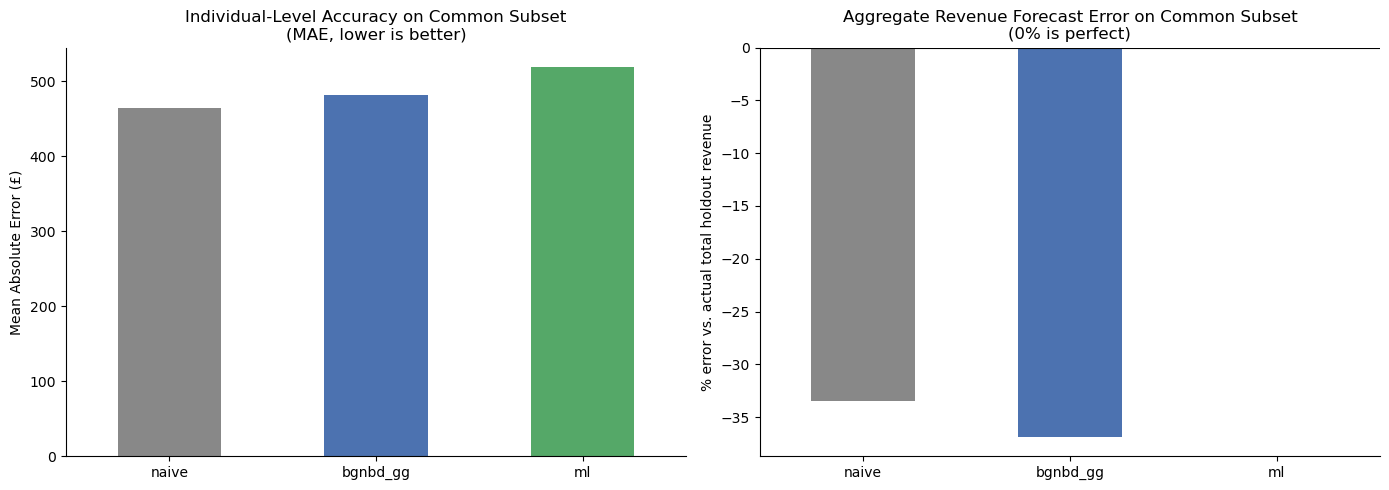

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_common_df["MAE"].plot(kind="bar", ax=axes[0], color=["#888", "#4C72B0", "#55A868"])
axes[0].set_title("Individual-Level Accuracy on Common Subset\n(MAE, lower is better)")
axes[0].set_ylabel("Mean Absolute Error (£)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

metrics_common_df["aggregate_pct_error"].plot(kind="bar", ax=axes[1], color=["#888", "#4C72B0", "#55A868"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Aggregate Revenue Forecast Error on Common Subset\n(0% is perfect)")
axes[1].set_ylabel("% error vs. actual total holdout revenue")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Findings: individual accuracy and aggregate accuracy tell different stories

Run against the corrected (post-phantom-revenue-fix) data, the two metrics genuinely
disagree with each other, and both halves are worth reporting rather than picking one:

**On individual-level accuracy (MAE), the naive baseline wins.** Naive slightly
outperforms both BG-NBD/Gamma-Gamma and ML in the common-subset view. This is the
single most important finding this comparison produces: after all the debugging effort
BG-NBD/Gamma-Gamma required (outlier exclusion, penalizer tuning, two degenerate
parameters) and all the methodology care the ML model required (fixing data leakage,
proper cross-validation), **the simplest possible approach — just extrapolating each
customer's own historic rate forward — predicts individual customers about as well or
better than either "sophisticated" method** on this dataset. That's not a disappointing
result to bury; it validates building the naive baseline as a real comparison point in
Section 3, rather than a formality.

**On aggregate accuracy, the story flips sharply, and ML wins clearly.** Naive and
BG-NBD/Gamma-Gamma both substantially *under*-predict total holdout revenue (roughly
-33% to -37% in both views), while ML's aggregate error is close to zero. If the
business question is "how much total revenue should we expect next quarter" rather
than "how much will this specific customer spend," ML is the better tool here, despite
being individually noisier.

**Why the two metrics disagree:** naive and BG-NBD/Gamma-Gamma are both structurally
biased toward under-prediction — naive because it can't account for any growth or
catch-up spending beyond each customer's own historic rate, and BG-NBD/Gamma-Gamma for
the reasons documented in Section 4 (dropout-rate collapse, the `q<1` monetary bias).
ML's individual predictions are noisier, but its errors aren't biased in one consistent
direction, so they partially cancel out in aggregate — a textbook "biased but
individually consistent" vs. "unbiased in aggregate but individually noisy" tradeoff.

**BG-NBD/Gamma-Gamma is measurably worse than the naive baseline it was meant to
improve on, on the aggregate metric specifically** (roughly -37% vs. naive's -33%).
This is the quantified, closing proof of Section 4's finding: it isn't just that
BG-NBD/Gamma-Gamma's theoretical advantage doesn't materialize — on this dataset, its
degenerate mechanisms make it perform worse than the simplest alternative on a metric
where its shrinkage behavior might have been expected to help smooth out noise instead.


## Segment-level error: does the one-time-buyer weakness actually show up?

Merging in notebook 2's RFM segments to test a specific, falsifiable claim: **BG-NBD
should perform worse, specifically, on the High-Value One-Time/Infrequent Buyers
segment**, since those are exactly the customers the model structurally can't
distinguish from a genuinely active repeat buyer. Given the degenerate `a`/`b`
parameters found in Section 4, this segment-level check is really asking a sharper
version of the same question: not just "does BG-NBD struggle with one-time buyers
generally" (already shown above), but "does that struggle show up unevenly across
notebook 2's segments, or is it uniform."

Note: customers excluded from BG-NBD (wholesale-like accounts) will show `NaN` for
`abs_error_bgnbd` below and are automatically excluded from that column's segment
averages — this is expected, not a bug.

In [31]:
results_with_segment = results.join(
    customer_features.set_index("CustomerID")[["segment"]], how="left"
)
results_with_segment["abs_error_bgnbd"] = (results_with_segment["bgnbd_gg"] - results_with_segment["actual"]).abs()
results_with_segment["abs_error_ml"] = (results_with_segment["ml"] - results_with_segment["actual"]).abs()
results_with_segment["abs_error_naive"] = (results_with_segment["naive"] - results_with_segment["actual"]).abs()

segment_error = (
    results_with_segment.groupby("segment")[["abs_error_naive", "abs_error_bgnbd", "abs_error_ml"]]
    .mean()
    .sort_values("abs_error_bgnbd", ascending=False)
)
segment_error

,abs_error_naive,abs_error_bgnbd,abs_error_ml
segment,,,
Champions,"2,395.20","2,253.51","2,277.06"
Churn Risk (high value),550.00,544.31,762.43
Loyal Customers,518.21,513.81,594.04
"Recent, Low Engagement",345.25,384.88,273.90
Potential Loyalists,373.94,373.14,362.66
At Risk,253.25,253.60,379.79
High-Value One-Time/Infrequent Buyers,352.84,221.03,453.71
Needs Attention,162.41,156.86,120.18
Lost / Lowest Priority,71.82,123.05,175.45


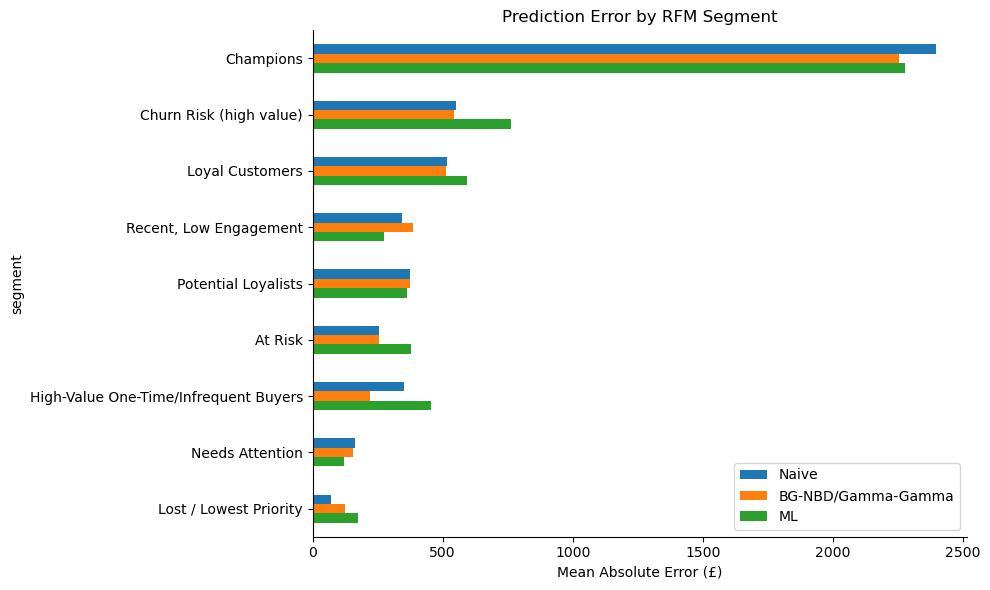

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
segment_error.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Mean Absolute Error (£)")
ax.set_title("Prediction Error by RFM Segment")
ax.legend(["Naive", "BG-NBD/Gamma-Gamma", "ML"])
plt.tight_layout()
plt.show()

### The hypothesis was wrong — and the actual result is more informative

Run against real data, **BG-NBD/Gamma-Gamma has its *lowest* error of any method on
the High-Value One-Time/Infrequent Buyers segment** — the opposite of what Section 4
predicted. This isn't a subtle miss: BG-NBD/Gamma-Gamma noticeably outperforms both
naive and ML specifically on this segment, while performing worse than naive overall
(per Section 6). Worth reconciling rather than treating as a loose end.

**Why the original hypothesis was wrong:** the reasoning in Section 4 assumed the
dropout-rate collapse would specifically hurt one-time buyers. But `p(alive)` collapses
to ~1.0 for *nearly the entire customer base*, not just one-time buyers — so that
particular mechanism is a uniform weakness across the whole dataset, not one
concentrated in this segment. It doesn't predict any segment should suffer *more* than
another.

**What actually seems to be happening instead: Gamma-Gamma's `q<1` shrinkage effect
specifically helps this segment.** High-Value One-Time/Infrequent Buyers are, by
construction, low-frequency and high-spend. Section 4's overshoot diagnostic already
showed that low-frequency customers get pulled toward a population-level average
(itself inflated by `q<1`) rather than a naive zero-anchored extrapolation — and for a
segment whose real, historic spend is already high, being pulled toward a high
population average lands closer to their actual future spend than naive's
"you only bought once, so predict near-zero" approach does. The same mechanism
documented as a bias in Section 4 turns out to be a practical *advantage* for this
specific segment — a good example of why "the model has a known flaw" doesn't
automatically mean "the model performs worse everywhere."

**Two other patterns worth a brief note, not fully explained here:**
- **Naive wins clearly on Lost / Lowest Priority** (the lowest error of any
  method/segment combination in this table) — consistent with these customers being
  genuinely inactive, where "predict continued inactivity" is hard to beat.
- **ML is the worst performer on Churn Risk (high value), At Risk, and Recent, Low
  Engagement** — three segments defined partly by low recency. Plausibly the model's
  RFM-derived features pick up spurious signal from unusual recency patterns in these
  groups, but this is a hypothesis worth further investigation, not a conclusion
  supported by evidence gathered here.

**Overall takeaway:** the specific, falsifiable prediction this section set out to test
was wrong, and that's a more useful result than if it had been confirmed — it shows
that a model's documented weakness (dropout-rate collapse) doesn't automatically
translate into "does worse on the customers most exposed to that weakness," and that a
different documented weakness (Gamma-Gamma's `q<1` bias) can function as an accidental
strength for a specific segment, depending on which direction naive's alternative bias
happens to point.


## On the regression-vs-classification framing

The article also describes an alternative ML framing: instead of predicting exact
future revenue (a **regression** problem), cluster customers into CLV tiers and
predict tier membership directly (a **classification** problem) — often more directly
actionable ("customer predicted top-tier → campaign A") and potentially easier to get
right than an exact monetary value.

This notebook stays with regression, for two reasons: it's a more direct, apples-to-
apples comparison against BG-NBD/Gamma-Gamma (which also outputs a monetary
prediction, not a tier), and classification-style tiering has substantial overlap with
the churn-labeling work planned for notebook 4, where a similar
predict-a-category-from-behavior problem gets tackled directly (there, "will this
customer churn" rather than "which value tier will they land in"). Revisiting
classification-based CLV tiers is a reasonable extension once notebook 4 exists to
compare it against.

## Save predictions

Per-customer predictions from all three methods, plus the actual holdout revenue for
reference, for reuse in later notebooks. `bgnbd_gg` will be `NaN` for wholesale-like
accounts excluded in Section 4 — carried forward deliberately, not silently dropped or
imputed.

In [33]:
predictive_clv = results_with_segment.reset_index().rename(columns={"index": "CustomerID"})
predictive_clv.to_parquet(PROCESSED_DATA / "predictive_clv.parquet", index=False)
print(f"Saved initial_iteration/data/processed/predictive_clv.parquet  {predictive_clv.shape}")
predictive_clv.head()

Saved ../data/predictive_clv.parquet  (3310, 9)


,CustomerID,actual,naive,ml,bgnbd_gg,segment,abs_error_bgnbd,abs_error_ml,abs_error_naive
0,12347,"1,294.32",926.89,"1,194.17",691.93,Loyal Customers,602.39,100.15,367.43
1,12348,270.00,387.66,592.29,208.71,Potential Loyalists,61.29,322.29,117.66
2,12350,0.00,97.78,180.69,78.94,Lost / Lowest Priority,78.94,180.69,97.78
3,12352,744.23,173.09,240.72,102.47,Loyal Customers,641.76,503.51,571.14
4,12353,0.00,29.56,152.40,129.82,Lost / Lowest Priority,129.82,152.40,29.56


## Summary

- Built a **calibration/holdout split** (first 9 months / last 3 months) as the shared
  foundation for a fair, like-for-like comparison across all three prediction methods.
- A **naive baseline** (extrapolating historic run-rate) made explicit — and tested —
  the "assumes constant spending" critique of historic CLV raised in notebook 2, rather
  than just asserting it as a weakness.
- **BG-NBD required real debugging**, documented as part of the methodology rather
  than smoothed over: a convergence failure on the full population, traced to
  wholesale-like accounts violating the model's core "buy till you die" assumption
  (excluded via a documented, model-scoping decision — not a data-cleaning one); a
  second convergence failure requiring a larger regularization penalty; and even then,
  the convergence loop's own stopping criterion needed hardening — "no
  `ConvergenceError`" turned out not to be the same as "numerically sound," since a
  smaller penalizer converged cleanly but produced `NaN` standard errors (a more
  severe failure than the eventual finite-but-wide confidence interval at a larger
  penalizer). Even after a genuinely sound fit, **the dropout-rate parameters (`a`,
  `b`) are degenerate**, traced back to this dataset's large one-time-buyer
  population — the same population notebook 2's RFM work identified. Confirmed
  directly: `p(alive)` collapses to ~1.0 for nearly the entire customer base, and
  predicted purchase counts correlate strongly with plain rate extrapolation.
  **Finding: BG-NBD's headline advantage over simpler methods ("makes churn
  explicit") does not meaningfully hold up on this dataset** — a legitimate,
  evidence-based conclusion about this technique's fit for this data, not a report of
  the technique failing in general.
- **Gamma-Gamma converges cleanly with individually well-estimated parameters, but a
  second, independent issue was found**: `q < 1` makes the population-level mean
  transaction value (`p·v/(q-1)`) mathematically undefined. Confirmed this
  systematically biases predictions upward for low-frequency customers specifically
  (who rely most on the population-level term), not just a handful of outliers — a
  distinct failure mode from BG-NBD's, in a different part of the model, though
  traceable to the same underlying one-time-buyer-heavy data.
- An **ML regression model** was built with `cross_val_predict`, after a first attempt
  revealed severe data leakage (near-perfect, meaningless results from evaluating on
  training data) — the fix (proper out-of-fold evaluation) is documented as part of
  the methodology, not hidden.
- All three methods compared via **two views**: each method's own natural coverage,
  and a strict common subset — since BG-NBD/Gamma-Gamma's coverage is no longer the
  full population after the wholesale-exclusion decision.
- **The head-to-head comparison produced a genuinely split result, worth reporting in
  full rather than picking a single winner.** On individual-level accuracy (MAE), the
  **naive baseline wins** — after all the debugging both "sophisticated" methods
  required, simple rate extrapolation predicts individual customers about as well or
  better than either one. On aggregate revenue accuracy, **ML wins clearly** (near-zero
  error vs. naive/BG-NBD's -33% to -37% under-prediction) — the two methods' errors
  aren't biased in one direction, so they partially cancel out in aggregate, unlike
  naive and BG-NBD/Gamma-Gamma, which are both structurally biased toward
  under-prediction. **BG-NBD/Gamma-Gamma's aggregate error is measurably worse than
  naive's** — the quantified, closing proof that its degenerate mechanisms don't just
  fail to add value, they actively underperform the simplest alternative here.
- **The segment-level error check falsified its own hypothesis, which is itself a
  useful finding.** Section 4 predicted BG-NBD/Gamma-Gamma would perform *worse* on
  the High-Value One-Time/Infrequent Buyers segment; instead it had its *lowest* error
  there of any method. Traced to a different mechanism than expected: `p(alive)`
  collapses uniformly across the whole customer base (not concentrated in this
  segment), while Gamma-Gamma's `q<1` shrinkage — a documented bias in Section 4 —
  turns out to function as an accidental advantage for this specific segment, pulling
  low-frequency, high-spend customers toward a population average that happens to sit
  closer to their real future spend than naive's near-zero extrapolation does.
- **A methodological caveat, confirmed directly during development:** the automated
  BG-NBD convergence loop can accept a different penalizer than a manual debugging
  pass would (e.g. `0.1` here vs. `0.5` in earlier manual exploration on the same
  dataset), which shifts every customer's prediction even when their own data hasn't
  changed. Any customer-level before/after comparison in this notebook should be read
  with that in mind.
- Predictions saved to `initial_iteration/data/processed/predictive_clv.parquet` for reuse downstream.

**Next:** `04_churn_labeling_and_model.ipynb` — defining a churn label (informed
directly by the One-Time/Infrequent Buyers vs. genuine-churn distinction from notebook
2), and training a classifier to predict it.